In [ ]:
import copy
import seaborn as sns
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

## Подготовка данных к обучению

In [ ]:
df = pd.read_csv('cybersequrity.csv')


In [ ]:
# Разделяем признаки (X) и целевую переменную (y)
X = df.drop('Class', axis=1).values
y = df['Class'].values

In [ ]:
# Сначала отделяем обучающую выборку (60%) от остальных (40%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    random_state=42,
    stratify=y
)

In [ ]:
# Теперь делим оставшиеся 40% пополам, чтобы получить 20% валидации и 20% теста
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

In [ ]:
print(f"Размеры выборок:")
print(f"Train: {X_train.shape} (60%)")
print(f"Val:   {X_val.shape} (20%)")
print(f"Test:  {X_test.shape} (20%)")

Размеры выборок:
Train: (6000, 15) (60%)
Val:   (2000, 15) (20%)
Test:  (2000, 15) (20%)


In [ ]:
# Стандартизация (StandardScaler)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [ ]:
# Создание класса DATASET
class CyberSecurityDataset(Dataset):
    def __init__(self, features, labels):
        # Конвертируем numpy array в тензоры PyTorch
        # float32 - стандарт для признаков нейросетей
        self.features = torch.tensor(features, dtype=torch.float32)
        # Для бинарной классификации (BCELoss) целевая переменная часто нужна в float,
        # и размерность (N, 1)
        self.labels = torch.tensor(labels, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

In [ ]:
# Создаем экземпляры Dataset
train_dataset = CyberSecurityDataset(X_train, y_train)
val_dataset = CyberSecurityDataset(X_val, y_val)
test_dataset = CyberSecurityDataset(X_test, y_test)

In [ ]:
# Выбор batch_size
# Для 10,000 строк размер 64 является хорошим балансом между скоростью и стабильностью градиента
# Если памяти GPU мало, можно уменьшить до 32. Если много - увеличить до 128 или 256
BATCH_SIZE = 64

In [ ]:
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# Для валидации и теста shuffle=False, так как порядок не важен для оценки
val_loader = DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
# Проверка работы (вывод одного батча)
features_batch, labels_batch = next(iter(train_loader))
print(f"\nПример батча:")
print(f"Размерность признаков: {features_batch.shape}")
print(f"Размерность меток: {labels_batch.shape}")


Пример батча:
Размерность признаков: torch.Size([64, 15])
Размерность меток: torch.Size([64, 1])


# Реализуйем класс бейзлайновой нейросетевой модели (MLP) для решения задачи

In [ ]:
# Определение устройства (GPU если есть, иначе CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Selected device: {device}")

Selected device: cpu


In [ ]:
class MalwareClassifierMLP(nn.Module):
    def __init__(self, input_dim):
        super(MalwareClassifierMLP, self).__init__()

        # Слой 1: Расширяем или держим размерность для поиска комбинаций признаков
        # Используем Linear + ReLU
        # BatchNorm помогает стабилизировать обучение и ускоряет сходимость
        # Dropout (0.3) предотвращает переобучение на небольшом датасете (10к строк)
        self.layer1 = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        # Слой 2: Сужаем представление данных
        self.layer2 = nn.Sequential(
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        # Выходной слой: Сводит все к одному числу (logit)
        self.output_layer = nn.Linear(32, 1)

        # Активация для бинарной классификации (вероятность 0..1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Проход данных по сети
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.output_layer(x)
        x = self.sigmoid(x)
        return x

In [ ]:
# Определение размерности входных данных
# X_train берем из предыдущего шага. X_train.shape[1] - это количество признаков (столбцов)
input_dim = X_train.shape[1]

# Создание объекта модели
model = MalwareClassifierMLP(input_dim)

# Перевод модели на GPU/CPU
model = model.to(device)

print(model)

MalwareClassifierMLP(
  (layer1): Sequential(
    (0): Linear(in_features=15, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
  )
  (layer2): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
  )
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


# Напишем код цикла обучения - train-loop и валидации - eval-loop

In [ ]:
# 1. Настройка обучения
criterion = nn.BCELoss() # Бинарная кросс-энтропия
optimizer = optim.Adam(model.parameters(), lr=0.001) # Learning Rate можно варьировать (1e-3 или 1e-4)

In [ ]:
EPOCHS = 30
train_losses = []
val_losses = []

In [ ]:
for epoch in range(EPOCHS):
    # --- TRAIN LOOP ---
    model.train()
    running_loss = 0.0

    for features, labels in train_loader:
        # Перенос данных на GPU/CPU
        features = features.to(device)
        labels = labels.to(device)

        # Обнуление градиентов
        optimizer.zero_grad()

        # Forward pass (прямое распространение)
        outputs = model(features)
        loss = criterion(outputs, labels)

        # Backward pass (обратное распространение)
        loss.backward()

        # Шаг оптимизатора (обновление весов)
        optimizer.step()

        running_loss += loss.item()

    # Средний лосс за эпоху
    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # --- EVAL LOOP ---
    model.eval() # Переводим модель в режим оценки
    running_val_loss = 0.0

    with torch.no_grad(): # Отключаем расчет градиентов для экономии памяти и времени
        for features, labels in val_loader:
            features = features.to(device)
            labels = labels.to(device)

            outputs = model(features)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(val_loader)
    val_losses.append(epoch_val_loss)

    # Вывод прогресса каждые 5 эпох
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}] | "
              f"Train Loss: {epoch_train_loss:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f}")

Epoch [1/30] | Train Loss: 0.6668 | Val Loss: 0.6569
Epoch [5/30] | Train Loss: 0.5655 | Val Loss: 0.5462
Epoch [10/30] | Train Loss: 0.5252 | Val Loss: 0.5959
Epoch [15/30] | Train Loss: 0.5175 | Val Loss: 0.5333
Epoch [20/30] | Train Loss: 0.5129 | Val Loss: 0.5339
Epoch [25/30] | Train Loss: 0.5039 | Val Loss: 0.5006
Epoch [30/30] | Train Loss: 0.4988 | Val Loss: 0.5538


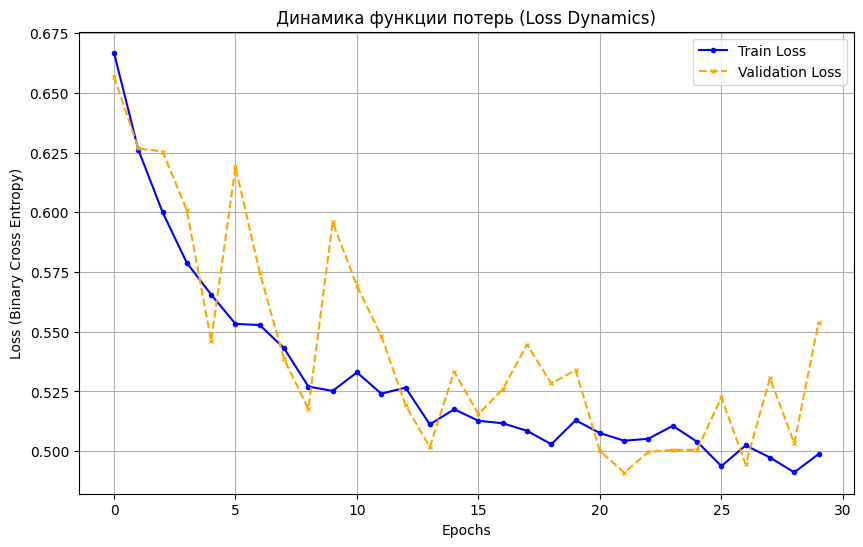

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss', color='blue', marker='o', markersize=3)
plt.plot(val_losses, label='Validation Loss', color='orange', linestyle='--', marker='x', markersize=3)
plt.title('Динамика функции потерь (Loss Dynamics)')
plt.xlabel('Epochs')
plt.ylabel('Loss (Binary Cross Entropy)')
plt.legend()
plt.grid(True)
plt.show()

# Напишем код цикла обучения - train-loop и валидации - eval-loop и обучим модель и проверим ее качество

In [ ]:
# 1. Инициализация модели и оптимизатора
# Используем input_dim из этапа подготовки данных
input_dim = X_train.shape[1]
model = MalwareClassifierMLP(input_dim).to(device)

# Оптимизатор Adam обычно показывает лучшие результаты для таких задач
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Функция потерь
criterion = nn.BCELoss()

# Параметры обучения
EPOCHS = 30
best_val_loss = float('inf')
best_model_wts = copy.deepcopy(model.state_dict()) # Для сохранения лучших весов

train_losses = []
val_losses = []

In [ ]:
for epoch in range(EPOCHS):
    # --- TRAIN ---
    model.train()
    running_loss = 0.0
    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # --- VALIDATION ---
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for features, labels in val_loader:
            features, labels = features.to(device), labels.to(device)
            outputs = model(features)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(val_loader)
    val_losses.append(epoch_val_loss)

    # Сохраняем модель, если она показала лучший результат на валидации
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_wts = copy.deepcopy(model.state_dict())

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}] Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

Epoch [5/30] Train Loss: 0.5681 | Val Loss: 0.5551
Epoch [10/30] Train Loss: 0.5332 | Val Loss: 0.5099
Epoch [15/30] Train Loss: 0.5174 | Val Loss: 0.5239
Epoch [20/30] Train Loss: 0.5131 | Val Loss: 0.5055
Epoch [25/30] Train Loss: 0.5033 | Val Loss: 0.4622
Epoch [30/30] Train Loss: 0.4970 | Val Loss: 0.4984


In [ ]:
print(f"Лучший Loss на валидации: {best_val_loss:.4f}")


Лучший Loss на валидации: 0.4622


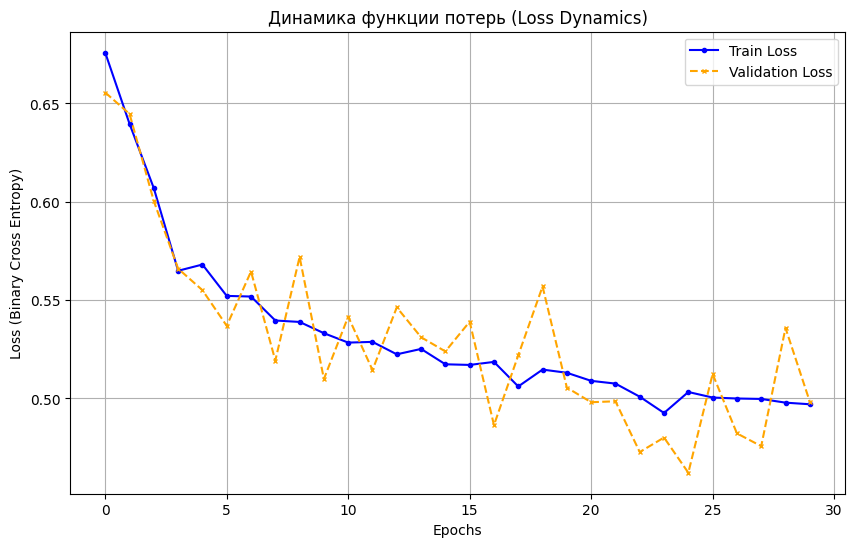

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss', color='blue', marker='o', markersize=3)
plt.plot(val_losses, label='Validation Loss', color='orange', linestyle='--', marker='x', markersize=3)
plt.title('Динамика функции потерь (Loss Dynamics)')
plt.xlabel('Epochs')
plt.ylabel('Loss (Binary Cross Entropy)')
plt.legend()
plt.grid(True)
plt.show()

=== Classification Report на тестовой выборке ===
              precision    recall  f1-score   support

 Neutral (0)       0.79      0.75      0.77       981
 Malware (1)       0.77      0.80      0.79      1019

    accuracy                           0.78      2000
   macro avg       0.78      0.78      0.78      2000
weighted avg       0.78      0.78      0.78      2000



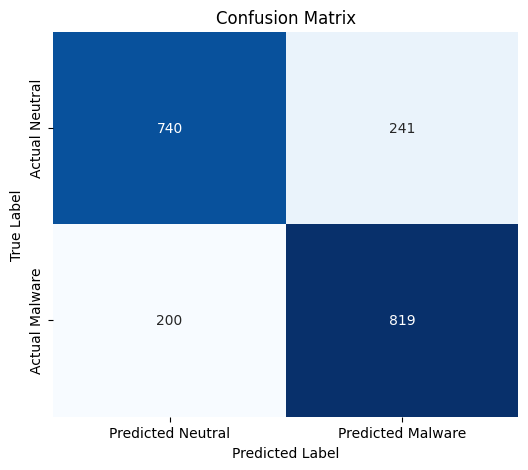

In [ ]:
# Загрузка лучших весов
model.load_state_dict(best_model_wts)

# Перевод в режим оценки
# Это отключает Dropout и переводит BatchNormalization в режим использования накопленной статистики
model.eval()

y_preds = []
y_true = []

# Проход по тестовой выборке
with torch.no_grad(): # Отключаем градиенты для ускорения и экономии памяти
    for features, labels in test_loader:
        features = features.to(device)

        # Получаем предсказания (вероятности от 0 до 1)
        outputs = model(features)

        # Переносим результаты на CPU и добавляем в список
        y_preds.extend(outputs.cpu().numpy())
        y_true.extend(labels.numpy())

# Обработка результатов
# Преобразуем списки в плоские numpy массивы
y_true = np.array(y_true).flatten()
y_probs = np.array(y_preds).flatten()

# Применяем пороговое значение (Threshold)
# Обычно 0.5. Если вероятность > 0.5, считаем класс 1 (Malware)
threshold = 0.5
y_pred_binary = (y_probs > threshold).astype(int)

# Вывод отчета о классификации
print("=== Classification Report на тестовой выборке ===")
print(classification_report(y_true, y_pred_binary, target_names=['Neutral (0)', 'Malware (1)']))

# Матрица ошибок (Confusion Matrix) ---
# Для задач кибербезопасности важно видеть не только точность,
# но и сколько вирусов мы пропустили (False Negative)
cm = confusion_matrix(y_true, y_pred_binary)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Neutral', 'Predicted Malware'],
            yticklabels=['Actual Neutral', 'Actual Malware'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Улучшим архитектуру модели из пункта 3 и добьемся увеличения качества

**BatchNorm1d (BN)**:

**Зачем**: Нормализует выходные данные слоя перед активацией. Это решает проблему внутреннего сдвига ковариации

**Где ставить**: Перед функцией активации (Linear -> BN -> Activation)

**Влияние**: Позволяет использовать более высокий Learning Rate, модель сходится быстрее и становится менее чувствительной к начальной инициализации весов

**Dropout**:

**Зачем**: Случайно "выключает" нейроны во время обучения. Это заставляет сеть не полагаться на один сильный признак, а распределять знания по всей сети

**Где ставить**: После функции активации (Activation -> Dropout). Если поставить до BN, это испортит накопление статистики

**Параметр p**:

*   **Для входного слоя**: обычно не используется или очень маленький (p=0.1), чтобы не терять сырые данные
*   **Для скрытых слоев**: оптимально 0.25 - 0.4 для табличных данных такого размера. p=0.5 здесь может быть слишком агрессивным и привести к недообучению, так как нейронов и так немного. Я выбрал p=0.3






In [ ]:
class ImprovedMalwareMLP(nn.Module):
    def __init__(self, input_dim):
        super(ImprovedMalwareMLP, self).__init__()

        self.net = nn.Sequential(
            # Входной блок: расширяем признаки
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),       # Нормализация
            nn.ReLU(),                 # Нелинейность
            nn.Dropout(0.3),           # Регуляризация

            # Скрытый блок 1
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Скрытый блок 2 (сужающий)
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2), # Чуть меньше dropout перед выходом

            # Выход
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

# Инициализация
input_dim = X_train.shape[1]
improved_model = ImprovedMalwareMLP(input_dim).to(device)
print(improved_model)

ImprovedMalwareMLP(
  (net): Sequential(
    (0): Linear(in_features=15, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
    (13): Sigmoid()
  )
)


**Изменения в процессе обучения**:

**Scheduler**: Добавляем *ReduceLROnPlateau*. Если Loss на валидации перестает падать, мы уменьшаем Learning Rate. Это помогает модели "аккуратно спуститься" в глобальный минимум в конце обучения

**Эпохи**: Увеличиваем до 50 (так как Dropout замедляет обучение, требуя больше проходов)

In [ ]:
# Гиперпараметры
criterion = nn.BCELoss()
optimizer = optim.Adam(improved_model.parameters(), lr=0.001)
# Планировщик: если val_loss не падает 5 эпох, уменьшаем LR в 10 раз
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)

EPOCHS = 50
best_loss = float('inf')
best_wts = copy.deepcopy(improved_model.state_dict())

train_losses = []
val_losses = []
lrs = [] # Для отслеживания LR

In [ ]:
for epoch in range(EPOCHS):
    # --- TRAIN ---
    improved_model.train()
    run_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        out = improved_model(X_batch)
        loss = criterion(out, y_batch)
        loss.backward()
        optimizer.step()

        run_loss += loss.item()

    avg_train_loss = run_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- VALIDATE ---
    improved_model.eval()
    run_val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            out = improved_model(X_batch)
            loss = criterion(out, y_batch)
            run_val_loss += loss.item()

    avg_val_loss = run_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    # Шаг шедулера
    scheduler.step(avg_val_loss)
    lrs.append(optimizer.param_groups[0]['lr'])

    # Сохранение лучшей модели
    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        best_wts = copy.deepcopy(improved_model.state_dict())

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | LR: {lrs[-1]:.1e}")

Epoch 5/50 | Train Loss: 0.5421 | Val Loss: 0.5640 | LR: 1.0e-03
Epoch 10/50 | Train Loss: 0.5033 | Val Loss: 0.5472 | LR: 1.0e-03
Epoch 15/50 | Train Loss: 0.4917 | Val Loss: 0.4784 | LR: 1.0e-03
Epoch 20/50 | Train Loss: 0.4751 | Val Loss: 0.5540 | LR: 1.0e-03
Epoch 25/50 | Train Loss: 0.4612 | Val Loss: 0.5599 | LR: 1.0e-04
Epoch 30/50 | Train Loss: 0.4478 | Val Loss: 0.4761 | LR: 1.0e-05
Epoch 35/50 | Train Loss: 0.4552 | Val Loss: 0.5026 | LR: 1.0e-05
Epoch 40/50 | Train Loss: 0.4563 | Val Loss: 0.4870 | LR: 1.0e-06
Epoch 45/50 | Train Loss: 0.4532 | Val Loss: 0.4744 | LR: 1.0e-07
Epoch 50/50 | Train Loss: 0.4545 | Val Loss: 0.4717 | LR: 1.0e-08


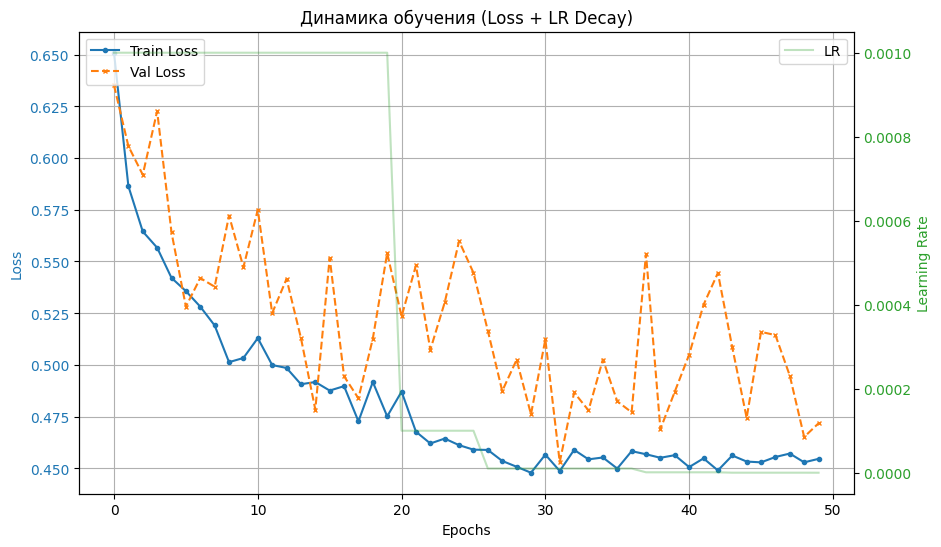

In [ ]:
# Визуализация
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss', color='tab:blue')
ax1.plot(train_losses, label='Train Loss', color='tab:blue', marker='o', markersize=3)
ax1.plot(val_losses, label='Val Loss', color='tab:orange', linestyle='--', marker='x', markersize=3)
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.legend(loc='upper left')

# Вторая ось для Learning Rate
ax2 = ax1.twinx()
ax2.set_ylabel('Learning Rate', color='tab:green')
ax2.plot(lrs, color='tab:green', alpha=0.3, label='LR')
ax2.tick_params(axis='y', labelcolor='tab:green')
ax2.legend(loc='upper right')

plt.title("Динамика обучения (Loss + LR Decay)")
ax1.grid(True)
plt.show()

Какой эффект получили? Как только Learning Rate падает, график Training Loss (синий) резко идет вниз - модель начинает "вгрызаться" в минимум, делая более точные и маленькие шаги. Валидация также становится стабильнее, а итоговый Loss ниже.

=== Classification Report (Improved Model) ===
              precision    recall  f1-score   support

     Neutral       0.81      0.77      0.79       981
     Malware       0.79      0.82      0.80      1019

    accuracy                           0.80      2000
   macro avg       0.80      0.80      0.80      2000
weighted avg       0.80      0.80      0.80      2000



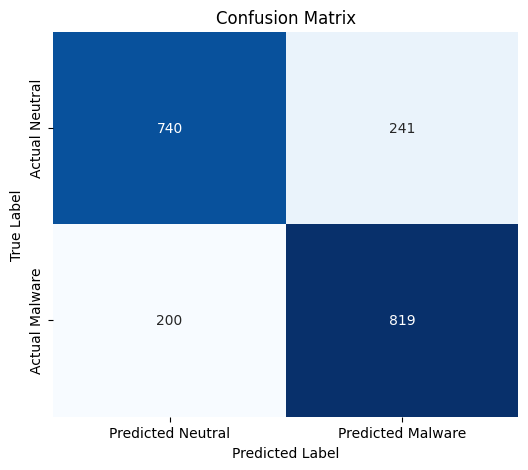

In [ ]:
# Загружаем лучшие веса
improved_model.load_state_dict(best_wts)
improved_model.eval()

y_preds = []
y_true = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = improved_model(X_batch)

        y_preds.extend(preds.cpu().numpy())
        y_true.extend(y_batch.numpy())

y_pred_bin = (np.array(y_preds) > 0.5).astype(int).flatten()
y_true_flat = np.array(y_true).flatten()

print("=== Classification Report (Improved Model) ===")
print(classification_report(y_true_flat, y_pred_bin, target_names=['Neutral', 'Malware']))

# Обработка результатов
# Преобразуем списки в плоские numpy массивы
y_true = np.array(y_true).flatten()
y_probs = np.array(y_preds).flatten()

# Матрица ошибок (Confusion Matrix) ---
# Для задач кибербезопасности важно видеть не только точность,
# но и сколько вирусов мы пропустили (False Negative)
cm = confusion_matrix(y_true, y_pred_binary)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Neutral', 'Predicted Malware'],
            yticklabels=['Actual Neutral', 'Actual Malware'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

Общая точность (accuracy) выросла с 0.78 до 0.80.

Также в задачах поиска вирусов главная метрика — это Recall для класса 1 (Malware):

*   До: Recall = 0.80
*   После: Recall = 0.82



      
      
      

